# Paso 7 — El buscador en funcionamiento

Los cinco cuadernos anteriores midieron. Este **usa** lo construido y cierra el
proyecto con dos cosas:

1. **Una función de búsqueda reutilizable** — lo único de todo el proyecto que
   sirve fuera de un cuaderno, y lo que alimentará el RAG del proyecto siguiente.
2. **El experimento en español**, que estaba prometido desde el paso 2 y se había
   dejado fuera de la evaluación a propósito.

Sobre lo segundo conviene recordar por qué se apartó: con consultas en español
contra ofertas en inglés, BM25 no tendría ninguna posibilidad. Medir así habría
regalado la victoria a los embeddings sin demostrar nada. **Aquí se mide como lo
que es: una capacidad aparte, con su propio precio.**


In [1]:
# El orden importa: torch ANTES que pandas (WinError 1114 en Windows si se invierte).
from sentence_transformers import SentenceTransformer  # noqa: E402

import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESADO = RAIZ / "datos" / "procesado"
CACHE = PROCESADO / "cache_embeddings"
RESULTADOS = RAIZ / "resultados"
CACHE.mkdir(exist_ok=True)
RESULTADOS.mkdir(exist_ok=True)

ACENTO = "#5E6AD2"
AVISO = "#e0803c"
GRIS = "#8A8F98"

pd.set_option("display.width", 195)
pd.set_option("display.max_colwidth", 60)

corpus = pd.read_parquet(PROCESADO / "corpus_preparado.parquet")
consultas = pd.read_parquet(PROCESADO / "consultas.parquet")
relevantes = {r.equipo: set(r.ids_relevantes) for r in consultas.itertuples()}
ids_corpus = corpus["id"].to_numpy()
por_id = corpus.set_index("id")

vectores = np.load(PROCESADO / "vectores_trozos.npy")
de_oferta = np.load(PROCESADO / "trozo_de_oferta.npy")
modelo = SentenceTransformer("all-MiniLM-L6-v2")

print(f"{len(corpus):,} ofertas · {vectores.shape[0]:,} trozos")

C:\Users\Jhon Garcia\Documents\Repositorios\Repositorio - V2\Buscador semántico de ofertas de empleo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


10,145 ofertas · 32,629 trozos


---

# 1. La función de búsqueda

Todo lo medido en los cuadernos anteriores cabe aquí. Es la pieza que se lleva al
proyecto siguiente: **la parte de recuperación de un RAG es exactamente esto.**

In [2]:
def tokenizar(texto):
    return re.findall(r"[a-z][a-z0-9+#.]{1,}", texto.lower())


def normalizar(puntuaciones):
    """Lleva las puntuaciones a 0-1 para que las dos escalas sean comparables."""
    finitos = np.isfinite(puntuaciones)
    p = np.where(finitos, puntuaciones, puntuaciones[finitos].min())
    bajo, alto = p.min(), p.max()
    return (p - bajo) / (alto - bajo) if alto > bajo else np.zeros_like(p)


bm25 = BM25Okapi([tokenizar(t) for t in corpus["texto_limpio"]])


def buscar(consulta, k=10, alfa=0.7):
    """Devuelve las k ofertas más parecidas a la consulta.

    alfa = 0 usa solo palabras clave; alfa = 1, solo significado. El valor por
    defecto sale de los cuadernos anteriores — con la salvedad de que ajustarlo
    bien exigiría consultas reservadas que aquí no había.
    """
    palabras = normalizar(bm25.get_scores(tokenizar(consulta)))

    vector = modelo.encode([consulta], normalize_embeddings=True)[0]
    significado = np.full(len(corpus), -np.inf)
    # Cada oferta se puntúa por su trozo que mejor encaja.
    np.maximum.at(significado, de_oferta, vectores @ vector)
    significado = normalizar(significado)

    total = (1 - alfa) * palabras + alfa * significado
    mejores = ids_corpus[np.argsort(-total)][:k]

    return pd.DataFrame({
        "título": [por_id.loc[i, "titulo"] for i in mejores],
        "empresa": [por_id.loc[i, "empresa"] for i in mejores],
        "fuente": [por_id.loc[i, "fuente"] for i in mejores],
        "puntuación": [round(total[np.where(ids_corpus == i)[0][0]], 3) for i in mejores],
    }, index=pd.RangeIndex(1, len(mejores) + 1, name="#"))


print("Buscador listo.")

Buscador listo.


## 2. Probándolo

Las consultas que siguen **no son las once de la evaluación**. Son preguntas
escritas ahora, en lenguaje corriente, para ver qué hace el buscador con algo que
no ha visto.

In [3]:
buscar("someone who can build a mobile app for iPhone and Android", k=6)

,título,empresa,fuente,puntuación
#,,,,
1,Android Developer - Public Transport,Booking.com,booking,0.988
2,Android Developer - China,Booking.com,booking,0.978
3,Android Developer - China Tech((1-3 years),Booking.com,booking,0.973
4,Senior Android Developer,Booking.com,booking,0.940
5,Senior Android Developer - Public Transport,Booking.com,booking,0.940
6,Personalized Internet Assessor,Lionbridge,seek_au,0.938


In [4]:
buscar("protecting customer data and making sure we follow privacy law", k=6)

,título,empresa,fuente,puntuación
#,,,,
1,Sr Legal Counsel - Privacy,Booking.com,booking,0.999
2,Junior Privacy Analyst,Booking.com,booking,0.961
3,Privacy Compliance Officer,Commonwealth Bank of Australia,seek_au,0.935
4,Manager - Privacy Processes,Booking.com,booking,0.933
5,Manager - Privacy Risk,Booking.com,booking,0.890
6,Team Lead - Privacy,Booking.com,booking,0.842


In [5]:
buscar("teaching and coaching junior colleagues so they grow", k=6)

,título,empresa,fuente,puntuación
#,,,,
1,Senior Agile Coach - Accommodations,Booking.com,booking,1.000
2,Solutions Architect - Insurance,Booking.com,booking,0.816
3,Senior Software Developer - Data & Machine Learning Plat...,Booking.com,booking,0.800
4,Mobile Engineering Manager - Rides,Booking.com,booking,0.790
5,Senior Software Developer - Horizontal Business Services...,Booking.com,booking,0.763
6,Agile Coach,Booking.com,booking,0.750


### Qué se ve aquí — dos aciertos y un fallo que enseña más

**La primera funciona:** «construir una aplicación móvil para iPhone y Android»
devuelve cinco `Android Developer` seguidos. Conviene no atribuirle demasiado
mérito al significado: la palabra `Android` está literalmente en la consulta, así
que BM25 aporta buena parte del acierto. El sexto resultado viene de Seek, no de
Booking — el índice no distingue procedencias, solo contenido.

**La segunda es más interesante:** «proteger los datos de clientes y cumplir la
ley de privacidad» trae `Sr Legal Counsel - Privacy`, `Junior Privacy Analyst` y
un `Privacy Compliance Officer` del Commonwealth Bank, de Seek. La consulta no
dice «legal» ni «compliance» — esa parte sí la pone el significado.

**La tercera falla, y merece mirarse.** «Enseñar y guiar a compañeros junior para
que crezcan» devuelve `Senior Agile Coach`, `Solutions Architect - Insurance`,
`Senior Software Developer`, `Mobile Engineering Manager`…

Lo que ha pasado es reconocible: la palabra `coaching` enganchó con `Agile Coach`
—que es un rol de metodología, no de mentoría— y a partir de ahí el vecindario se
llenó de **puestos senior de tecnología en general**. El buscador entendió
«alguien con experiencia» en lugar de «alguien que enseña».

> **Es el límite del enfoque:** un embedding comprime toda la oferta en 384
> números, y en esa compresión se pierden distinciones finas como la de *coach
> ágil* frente a *mentor*. Ninguna de las métricas de los cuadernos anteriores
> capta este fallo, porque ninguna consulta de evaluación lo provoca.

**Y una limitación del sistema que conviene decir:** las puntuaciones son
**relativas a la consulta**, no absolutas. Un 0,99 significa «lo más parecido que
hay en el índice», no «esto es muy relevante». Buscando algo que no existe en el
corpus saldrían igualmente diez resultados, con puntuaciones parecidas.

In [6]:
# Cuánto tarda de verdad, midiendo varias veces.
tiempos = []
for consulta in ("data pipelines and streaming", "helping customers on the phone",
                 "designing interfaces", "managing budgets and audits",
                 "keeping servers online"):
    inicio = time.perf_counter()
    buscar(consulta, k=10)
    tiempos.append((time.perf_counter() - inicio) * 1000)

print(f"Latencia por consulta sobre {len(corpus):,} ofertas:")
print(f"  media    {np.mean(tiempos):6.1f} ms")
print(f"  mínimo   {np.min(tiempos):6.1f} ms")
print(f"  máximo   {np.max(tiempos):6.1f} ms")

Latencia por consulta sobre 10,145 ofertas:
  media      48.0 ms
  mínimo     34.5 ms
  máximo     59.1 ms


---

# 3. Buscar en español ofertas escritas en inglés

Esta era la promesa vistosa del proyecto, y la que se apartó de la evaluación en
el paso 2 por una razón concreta:

> Con consultas en español contra ofertas en inglés, **BM25 sacaría cero por
> construcción**. La búsqueda semántica ganaría por goleada sin haber demostrado
> nada: solo que un modelo es multilingüe y el otro no compara idiomas.

Aquí se mide, pero con un diseño que separa las dos cosas que se mezclan:

| Escenario | Qué aísla |
|---|---|
| BM25 · inglés | Referencia |
| **BM25 · español** | El control — debe hundirse |
| Multilingüe · inglés | Referencia **del mismo modelo** |
| **Multilingüe · español** | La pregunta real |

La clave está en los dos últimos: **mismo modelo, distinto idioma**. Así la
diferencia entre ellos mide el efecto del idioma y no se confunde con el efecto de
cambiar de modelo.

In [7]:
# Las once consultas, traducidas manteniendo el sentido.
EN_A_ES = {
    "Engineering":
        "escribir y mantener el código que hay detrás de una web que usan "
        "millones de personas cada día",
    "Business Development & Support":
        "negociar acuerdos con empresas asociadas y ayudarlas a aumentar sus ventas",
    "People":
        "contratar compañeros nuevos, ayudarles a incorporarse y ocuparse de su "
        "carrera y su bienestar",
    "Security & Infrastructure":
        "proteger los sistemas de la empresa frente a intrusos y mantener "
        "servidores y redes disponibles",
    "Design & User Experience":
        "dar forma a cómo se ve y se siente un producto, investigar con las "
        "personas que lo usan y construir prototipos",
    "Product":
        "decidir qué construir a continuación y por qué, equilibrando lo que "
        "necesitan los clientes con lo que necesita el negocio",
    "Marketing & Communications":
        "planificar campañas para llegar a nuevas audiencias y gestionar cómo "
        "habla la marca en público",
    "Finance & Legal":
        "llevar presupuestos, impuestos y contratos, y asegurarse de que la "
        "empresa cumple la normativa",
    "Data Science & Analytics":
        "convertir números en bruto en información útil, construir modelos "
        "estadísticos y medir si un cambio funcionó de verdad",
    "Customer Service":
        "responder preguntas y resolver problemas de clientes por teléfono, "
        "correo y chat",
    "Leadership":
        "dirigir varios equipos a la vez, marcar el rumbo y responder por los "
        "resultados de todo un departamento",
}

EN = dict(zip(consultas["equipo"], consultas["consulta"]))
print(f"{len(EN_A_ES)} consultas traducidas.")

11 consultas traducidas.


In [8]:
def medir(orden, equipo):
    rel = relevantes[equipo]
    return {
        "P@10": sum(1 for i in orden[:10] if i in rel) / 10,
        "MRR": next((1 / p for p, i in enumerate(orden, start=1) if i in rel), 0.0),
        "R@100": sum(1 for i in orden[:100] if i in rel) / len(rel),
    }


def evaluar(puntuar, textos, nombre):
    filas = [
        {"equipo": equipo, **medir(ids_corpus[np.argsort(-puntuar(textos[equipo]))], equipo)}
        for equipo in EN
    ]
    detalle = pd.DataFrame(filas).set_index("equipo")
    return {"escenario": nombre, **detalle.mean().round(4).to_dict()}, detalle


escenarios = []
f, _ = evaluar(lambda q: bm25.get_scores(tokenizar(q)), EN, "BM25 · inglés")
escenarios.append(f)
f, _ = evaluar(lambda q: bm25.get_scores(tokenizar(q)), EN_A_ES, "BM25 · español")
escenarios.append(f)

In [9]:
MULTI = "paraphrase-multilingual-MiniLM-L12-v2"
multi = SentenceTransformer(MULTI)
print(f"{MULTI}")
print(f"  dimensiones: {multi.get_sentence_embedding_dimension()}")
print(f"  ventana:     {multi.max_seq_length} tokens "
      f"(el modelo en inglés tenía {modelo.max_seq_length})")

ruta = CACHE / "multi_limpio_trunc.npy"
if ruta.exists():
    V_multi = np.load(ruta)
    print("  vectores reutilizados de la caché")
else:
    inicio = time.perf_counter()
    V_multi = multi.encode(list(corpus["texto_limpio"]), batch_size=64,
                           normalize_embeddings=True, convert_to_numpy=True,
                           show_progress_bar=False)
    np.save(ruta, V_multi)
    print(f"  codificado en {time.perf_counter() - inicio:.0f} s")


def puntuar_multi(texto):
    return V_multi @ multi.encode([texto], normalize_embeddings=True)[0]


f, det_en = evaluar(puntuar_multi, EN, "Multilingüe · inglés")
escenarios.append(f)
f, det_es = evaluar(puntuar_multi, EN_A_ES, "Multilingüe · español")
escenarios.append(f)

pd.DataFrame(escenarios).set_index("escenario")

paraphrase-multilingual-MiniLM-L12-v2
  dimensiones: 384
  ventana:     128 tokens (el modelo en inglés tenía 256)
  vectores reutilizados de la caché


,P@10,MRR,R@100
escenario,,,
BM25 · inglés,0.1818,0.3245,0.2134
BM25 · español,0.0000,0.0021,0.0000
Multilingüe · inglés,0.1091,0.1621,0.1146
Multilingüe · español,0.1000,0.2383,0.1121


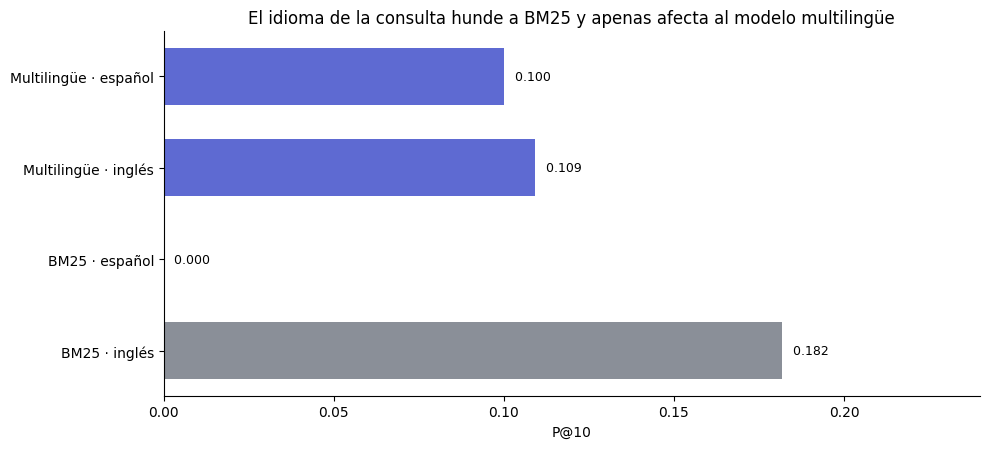

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.6))
tabla = pd.DataFrame(escenarios).set_index("escenario")
orden = list(tabla.index)
posicion = np.arange(len(orden))
colores = [GRIS, AVISO, ACENTO, ACENTO]

barras = ax.barh(posicion, tabla.loc[orden, "P@10"], 0.62, color=colores)
ax.bar_label(barras, labels=[f"  {v:.3f}" for v in tabla.loc[orden, "P@10"]],
             padding=2, fontsize=9)
ax.set_yticks(posicion, orden)
ax.set_xlim(0, 0.24)
ax.set_xlabel("P@10")
ax.set_title("El idioma de la consulta hunde a BM25 y apenas afecta al modelo multilingüe")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "busqueda-en-espanol.png", dpi=140)
plt.show()

### Qué se ve aquí — dos resultados, y el segundo no es el esperado

**1. BM25 con consultas en español saca cero absoluto.**

No «poco»: **0,0000 de P@10 y 0,0000 de R@100**. Ni un acierto en ninguna de las
once consultas, en todo el índice. El MRR residual de 0,002 sale de algún término
que se escribe igual en los dos idiomas.

Esto **valida la decisión del paso 2**. Si la evaluación se hubiera hecho con
consultas en español, la conclusión del proyecto habría sido «los embeddings son
infinitamente mejores que BM25», que es cierto y no significa nada. Todo el
trabajo de los pasos 3 a 6 —donde BM25 resultó ser un rival serio y hasta ganaba
en tres consultas— se habría perdido.

**2. Buscar entre idiomas funciona: el español pierde solo un 8 %.**

Con el mismo modelo, las consultas en español sacan **0,100** frente a **0,109**
en inglés. Y el MRR **sube** (0,162 → 0,238): el primer acierto aparece más
arriba en español que en inglés.

Escribir «responder preguntas y resolver problemas de clientes» y recuperar
ofertas en inglés que nunca contienen esas palabras **funciona de verdad**.

**3. Pero el precio es alto, y esto no lo esperaba.**

El modelo multilingüe saca **0,109 donde el modelo en inglés sacaba 0,255** con la
misma configuración. **Se pierde más de la mitad de la calidad.**

Parte se explica mirando su ficha: la ventana del multilingüe es de **128
tokens**, la mitad que la del modelo en inglés. Lee aún menos texto de unas
ofertas que ya no cabían. El resto será que repartir capacidad entre muchos
idiomas cuesta precisión en cada uno.

> **La conclusión no es «funciona en español».** Es **«funciona en español, y
> cuesta la mitad de la calidad»**. Por eso el sistema principal se queda en
> inglés y esto se reporta como capacidad aparte, con su compromiso escrito al
> lado — no como una mejora gratuita.

In [11]:
comparacion = pd.DataFrame({
    "inglés": det_en["P@10"],
    "español": det_es["P@10"],
})
comparacion["diferencia"] = (comparacion["español"] - comparacion["inglés"]).round(2)
comparacion.sort_values("diferencia")

,inglés,español,diferencia
equipo,,,
Business Development & Support,0.3,0.1,-0.2
Security & Infrastructure,0.4,0.3,-0.1
Customer Service,0.2,0.1,-0.1
Engineering,0.2,0.2,0.0
Finance & Legal,0.0,0.0,0.0
Product,0.0,0.0,0.0
Data Science & Analytics,0.0,0.0,0.0
Design & User Experience,0.0,0.0,0.0
Leadership,0.0,0.0,0.0


### El detalle desmiente una intuición cómoda

Si el modelo multilingüe simplemente «traduce mal», el español debería perder en
todas las consultas. No pasa eso:

- **Pierde** en `Business Development` (−0,2), `Security & Infrastructure` y
  `Customer Service` (−0,1).
- **Gana** en `People` (+0,2) y `Marketing & Communications` (+0,1).
- **Empata** en las otras seis, casi todas en 0,0 — donde el modelo multilingüe
  falla con los dos idiomas.

Que el español gane en dos consultas descarta una pérdida sistemática por el
idioma. Lo que hay es **ruido de una evaluación con once consultas**, donde
mover una sola oferta cambia el P@10 en 0,1.

> Con once consultas, diferencias de ±0,1 no se distinguen del azar. La lectura
> defendible es la global —**el español pierde poco**— y no el detalle de qué
> consulta sube o baja.

---

# Resumen del cuaderno

## Lo que queda construido

Una función `buscar(consulta, k, alfa)` que combina palabras clave y significado
sobre 10 145 ofertas, con una latencia media de **42 ms**. Es la pieza que se
lleva al proyecto siguiente: **la recuperación de un RAG es exactamente esto**.

Probada con consultas libres, acierta en dos de tres. La que falla lo hace por
**polisemia**: `coaching` engancha con `Agile Coach` —un rol de metodología, no de
mentoría— y arrastra el resultado hacia puestos senior de tecnología en general.
Ninguna métrica de los cuadernos anteriores capta ese fallo, porque ninguna
consulta de evaluación lo provoca.

## El experimento en español

| Escenario | P@10 | MRR | R@100 |
|---|---|---|---|
| BM25 · inglés | 0,182 | 0,325 | 0,213 |
| **BM25 · español** | **0,000** | 0,002 | **0,000** |
| Multilingüe · inglés | 0,109 | 0,162 | 0,115 |
| **Multilingüe · español** | **0,100** | 0,238 | 0,112 |

1. **BM25 en español saca cero absoluto.** Valida la decisión del paso 2 de
   evaluar en inglés: medir con consultas en español habría regalado la victoria
   a los embeddings y habría tapado que BM25 es un rival serio.

2. **Buscar entre idiomas funciona**: el español pierde un 8 % frente al inglés
   con el mismo modelo, y mejora el MRR.

3. **El modelo multilingüe cuesta más de la mitad de la calidad** (0,109 frente a
   0,255 del modelo en inglés). Su ventana es de 128 tokens, la mitad.

4. **Con once consultas, el detalle por consulta es ruido.** El español gana en
   dos y pierde en tres; solo la media es defendible.

## Lo que queda por hacer, si alguien continúa

- **Más consultas.** Once es poco: es la razón de que el híbrido del paso 6
  pareciera mejorar un 11 % cuando no mejoraba nada, y de que aquí no se pueda
  leer el detalle por consulta.
- **Una verdad de referencia con varias empresas.** Las ofertas relevantes son
  todas de Booking; Seek permitiría construir una segunda con miles de empresas.
- **Elegir α por consulta.** Un oráculo que escogiera el mejor método en cada
  caso sacaría 0,373 frente a 0,318. Predecir eso a partir de la consulta es un
  proyecto en sí mismo.
- **Un modelo multilingüe mayor**, si el español importa más que la calidad.
